# PIV Subset QC & Visualization — `subset_pix20_10000`

A 10,000-sample `pix20` slice of the 100k 2-D-turbulence PIV dataset, pulled to local
storage for verification during the Unity downtime.

**Each sample file** `pix20/seedN_pix20.jld2` holds **one image pair**:
- `pairs/<k>/A`, `pairs/<k>/B` — uint8 512×512 particle images = the **network inputs**
- `pairs/<k>/fields/{uA,vA,uB,vB}` — float32 512×512 velocity fields = the **ground-truth labels** at frames A and B

**Contents**
1. Load the manifest & match it to the downloaded files
2. Integrity scan — every `.jld2` opens with the expected structure
3. Missing / duplicate / out-of-manifest seed checks
4. Distributions of displacement & physical parameters
5. **The displacement knife-edge** — why this "20 px" bin is really a 15/20 px mix
6. Visualize image pairs (inputs) + velocity labels
7. Label sanity — finite values, displacement magnitude, A→B decorrelation
8. Flow diversity across seeds
9. Summary verdict

## 0. Config & helpers

In [1]:
import os, h5py, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- EDIT THIS if you move the data ----
DATA_DIR = "/Volumes/MODIS_L2_Orbits/AQUA/arup_piv/subset_pix20_10000"
BIN      = "pix20"
# ----------------------------------------
PIX_DIR  = os.path.join(DATA_DIR, BIN)
META_DIR = os.path.join(DATA_DIR, "metadata")
MANIFEST = os.path.join(DATA_DIR, "manifest.parquet")
plt.rcParams["figure.dpi"] = 110

print("DATA_DIR:", DATA_DIR)
print("exists  :", os.path.isdir(DATA_DIR), "| pix dir:", os.path.isdir(PIX_DIR))

DATA_DIR: /Volumes/MODIS_L2_Orbits/AQUA/arup_piv/subset_pix20_10000
exists  : True | pix dir: True


In [2]:
def pair_path(seed):
    return os.path.join(PIX_DIR, f"seed{seed}_{BIN}.jld2")

def load_pair(path):
    # One image pair per file. Returns A,B (uint8 512x512) + uA,vA,uB,vB (float32).
    with h5py.File(path, "r") as f:
        g = f["pairs"]; key = list(g.keys())[0]
        p = g[key]
        out = {"A": p["A"][:], "B": p["B"][:]}
        for k in ["uA", "vA", "uB", "vB"]:
            out[k] = p["fields"][k][:]
    return out

def speed(u, v):     return np.sqrt(u*u + v*v)
def vorticity(u, v): return np.gradient(v, axis=1) - np.gradient(u, axis=0)

# NOTE: JLD2 (Julia, column-major) is read transposed by h5py. Square 512x512 fields
# are unaffected in shape; only orientation is cosmetic. This matters for the
# exploratory warp check in section 7b, NOT for the integrity/statistics checks.

## 1. Load the manifest & match it to the downloaded files

In [3]:
mf = pd.read_parquet(MANIFEST)
print("manifest rows x cols:", mf.shape, " (indexes ALL 100k sims)")

present = sorted(
    int(p.name.replace("seed", "").replace(f"_{BIN}.jld2", ""))
    for p in Path(PIX_DIR).glob(f"seed*_{BIN}.jld2")
)
n_meta = len(list(Path(META_DIR).glob("*.toml")))
print(f"{BIN} files on disk  : {len(present)}")
print(f"metadata TOMLs     : {n_meta}")

sub = mf[mf["seed"].isin(present)].copy().sort_values("seed").reset_index(drop=True)
print(f"manifest rows for downloaded subset: {len(sub)}")
sub.head()

manifest rows x cols: (100000, 48)  (indexes ALL 100k sims)
pix20 files on disk  : 10000
metadata TOMLs     : 10000
manifest rows for downloaded subset: 10000


,advection,julia_version,git_sha,nt,m_jet,extent,jet_amp_arg,git_dirty,grid_N,stop_time,...,dp_pix10,dp_pix30,dp_pix20,realized_px_pix20,nframes,sample_pix10,sample_pix20,sample_pix30,combined_raw,metadata_file
0,WENO(order=5),1.12.6,d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9,40,2,512.0,300.0,true,512,14.918028,...,2,6,4,19.992171,41,pix10/seed1000001_pix10.jld2,pix20/seed1000001_pix20.jld2,pix30/seed1000001_pix30.jld2,combined/seed1000001.jld2,seed1000001.toml
1,WENO(order=5),1.12.6,d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9,40,2,512.0,300.0,true,512,16.186993,...,1,5,3,15.005170,41,pix10/seed1000002_pix10.jld2,pix20/seed1000002_pix20.jld2,pix30/seed1000002_pix30.jld2,combined/seed1000002.jld2,seed1000002.toml
2,WENO(order=5),1.12.6,d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9,40,2,512.0,300.0,true,512,13.812029,...,2,6,4,19.971966,41,pix10/seed1000003_pix10.jld2,pix20/seed1000003_pix20.jld2,pix30/seed1000003_pix30.jld2,combined/seed1000003.jld2,seed1000003.toml
3,WENO(order=5),1.12.6,d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9,40,2,512.0,300.0,true,512,11.812379,...,1,5,3,15.011416,41,pix10/seed1000004_pix10.jld2,pix20/seed1000004_pix20.jld2,pix30/seed1000004_pix30.jld2,combined/seed1000004.jld2,seed1000004.toml
4,WENO(order=5),1.12.6,d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9,40,2,512.0,300.0,true,512,23.139761,...,1,5,3,15.008892,41,pix10/seed1000005_pix10.jld2,pix20/seed1000005_pix20.jld2,pix30/seed1000005_pix30.jld2,combined/seed1000005.jld2,seed1000005.toml


In [13]:
# print 1 row of sub
print(sub.iloc[0])

advection                                                  WENO(order=5)
julia_version                                                     1.12.6
git_sha                         d61623ff8f6746d6e2b2bf4d93455fb2bf0556a9
nt                                                                    40
m_jet                                                                  2
extent                                                             512.0
jet_amp_arg                                                        300.0
git_dirty                                                           true
grid_N                                                               512
stop_time                                                      14.918028
viscosity_nu                                                     0.00001
grid_M                                                               512
seed                                                             1000001
n_max                                              

## 2. Integrity scan — every file opens with the expected structure

Opens each `.jld2` and checks the group layout **without** loading pixel data. Over an SMB share this may take a minute or two for 10k files.

In [4]:
bad = []
for s in present:
    try:
        with h5py.File(pair_path(s), "r") as f:
            g = f["pairs"]; k = list(g.keys())[0]; p = g[k]
            assert p["A"].shape == (512, 512) and p["B"].shape == (512, 512)
            for fld in ["uA", "vA", "uB", "vB"]:
                assert p["fields"][fld].shape == (512, 512)
    except Exception as e:
        bad.append((s, repr(e)))

print(f"scanned {len(present)} files -> {len(bad)} bad")
if bad:
    for s, e in bad[:10]:
        print("  BAD", s, e)
else:
    print("ALL FILES OPEN & HAVE THE EXPECTED STRUCTURE")

scanned 10000 files -> 0 bad
ALL FILES OPEN & HAVE THE EXPECTED STRUCTURE


## 3. Missing / duplicate / out-of-manifest checks

In [5]:
seeds_disk = set(present)
seeds_meta = set(int(p.name.replace("seed", "").replace(".toml", ""))
                 for p in Path(META_DIR).glob("*.toml"))

print("pix20 files with NO metadata TOML :", len(seeds_disk - seeds_meta))
print("metadata with NO pix20 file       :", len(seeds_meta - seeds_disk))
print("seeds NOT found in manifest       :", len(seeds_disk - set(mf["seed"])))
print("duplicate seeds in subset         :", len(present) - len(set(present)))
lo, hi = min(present), max(present)
print(f"seed range                        : {lo} .. {hi}")
print("contiguous (no gaps)              :", present == list(range(lo, lo + len(present))))

pix20 files with NO metadata TOML : 0
metadata with NO pix20 file       : 0
seeds NOT found in manifest       : 0
duplicate seeds in subset         : 0
seed range                        : 1000001 .. 1010000
contiguous (no gaps)              : True


## 4. Distributions of displacement & physical parameters

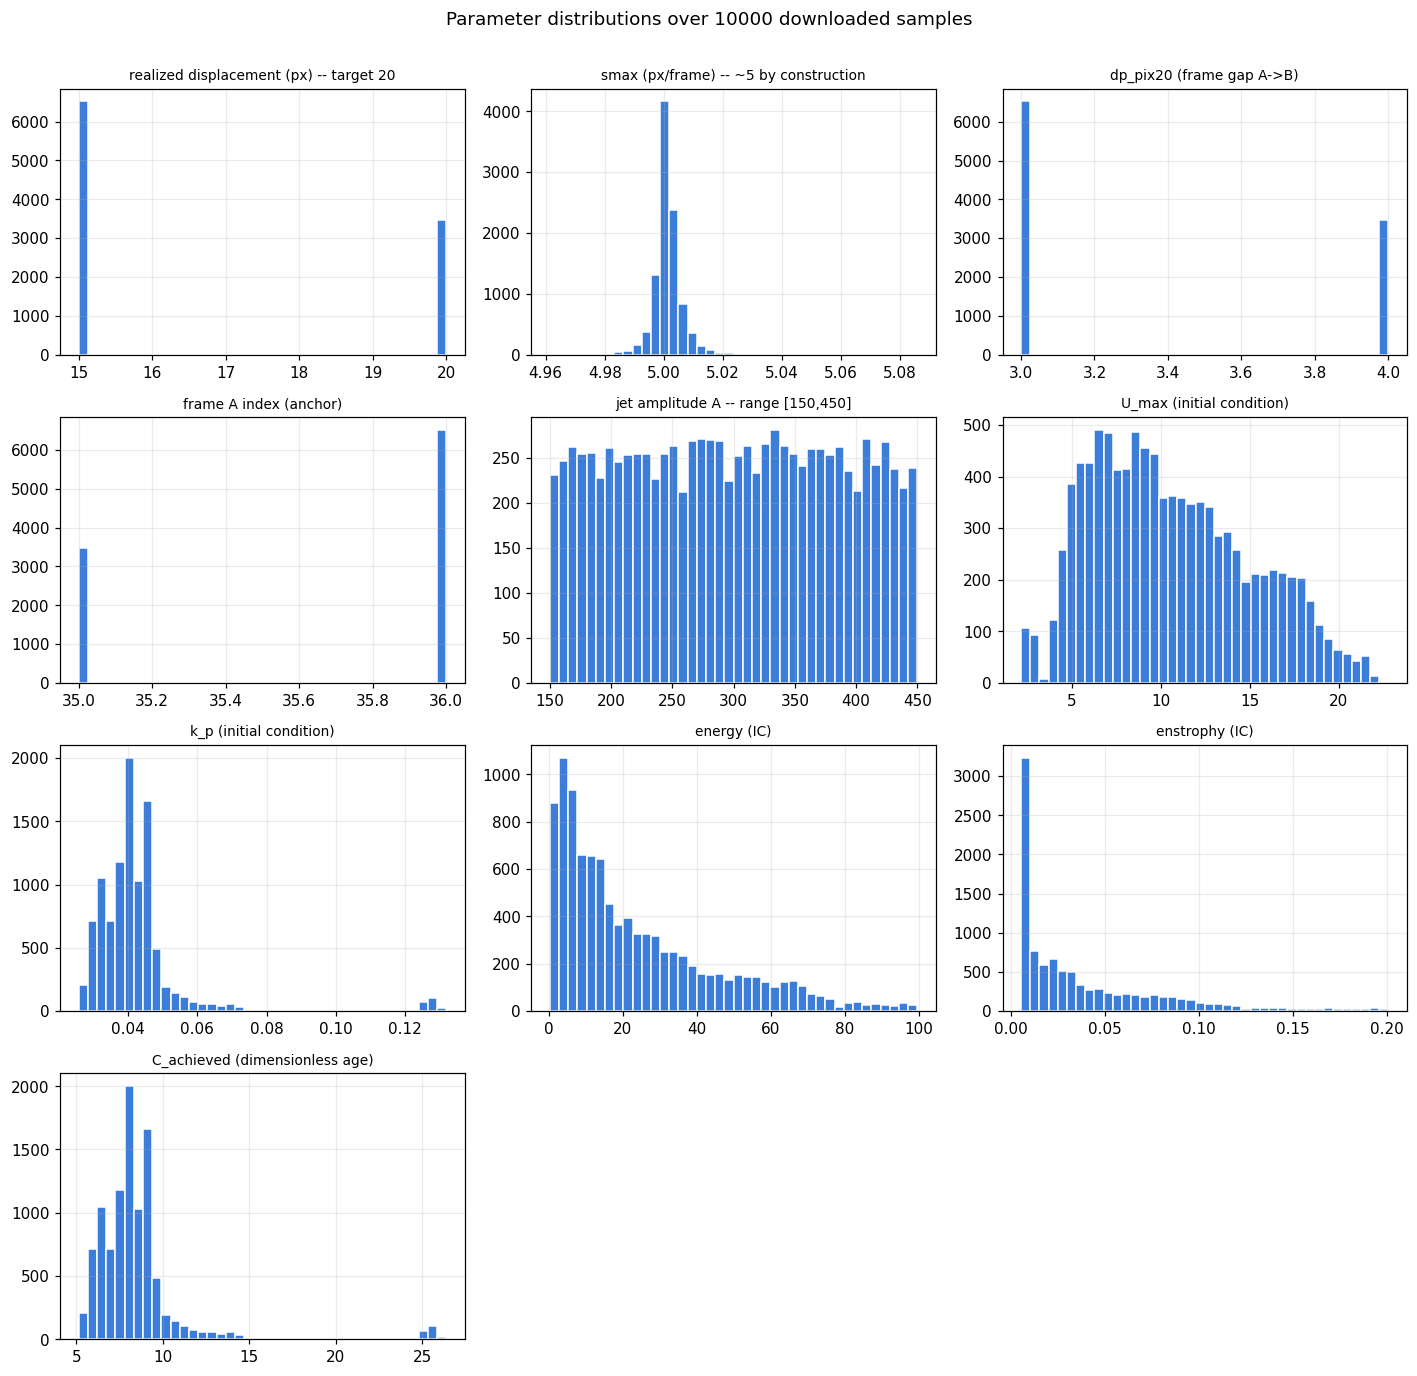

,count,mean,std,min,25%,50%,75%,max
realized_px_pix20,10000.0,16.740161,2.370386,15.000000,15.005217,15.014765,19.986920,20.000000
smax,10000.0,5.001378,0.005070,4.961394,4.999369,5.000925,5.003325,5.086028
dp_pix20,10000.0,3.347400,0.476168,3.000000,3.000000,3.000000,4.000000,4.000000
frameA_index,10000.0,35.652600,0.476168,35.000000,35.000000,36.000000,36.000000,36.000000
A_jet_amplitude,10000.0,299.678006,85.793724,150.022644,225.427205,300.089677,372.819326,449.992803
U_max_ic,10000.0,10.557828,4.386490,2.160599,6.986306,9.880703,13.651135,22.786225
k_p_ic,10000.0,0.042450,0.014330,0.025708,0.035597,0.040407,0.045233,0.131852
energy_ic,10000.0,23.804610,21.708571,0.347068,6.719140,15.997262,34.789032,99.511399
enstrophy_ic,10000.0,0.039303,0.040476,0.005533,0.008740,0.023087,0.057397,0.200595
C_achieved,10000.0,8.490000,2.865907,5.141609,7.119356,8.081499,9.046684,26.370463


In [6]:
cols = [
    ("realized_px_pix20", "realized displacement (px) -- target 20"),
    ("smax",              "smax (px/frame) -- ~5 by construction"),
    ("dp_pix20",          "dp_pix20 (frame gap A->B)"),
    ("frameA_index",      "frame A index (anchor)"),
    ("A_jet_amplitude",   "jet amplitude A -- range [150,450]"),
    ("U_max_ic",          "U_max (initial condition)"),
    ("k_p_ic",            "k_p (initial condition)"),
    ("energy_ic",         "energy (IC)"),
    ("enstrophy_ic",      "enstrophy (IC)"),
    ("C_achieved",        "C_achieved (dimensionless age)"),
]
cols = [(c, t) for c, t in cols if c in sub.columns]
ncol = 3; nrow = int(np.ceil(len(cols) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(13, 3.1 * nrow)); ax = ax.ravel()
for i, (c, t) in enumerate(cols):
    ax[i].hist(sub[c].dropna(), bins=40, color="#3b7dd8", edgecolor="white", lw=0.3)
    ax[i].set_title(t, fontsize=9); ax[i].grid(alpha=0.25)
for j in range(len(cols), len(ax)): ax[j].axis("off")
fig.suptitle(f"Parameter distributions over {len(sub)} downloaded samples", y=1.005, fontsize=12)
fig.tight_layout(); plt.show()
sub[[c for c, _ in cols]].describe().T

## 5. The displacement knife-edge — this "20 px" bin is really a 15/20 px mix

The frame gap is `dp = floor(pix / smax)`. Because `smax` sits right at **5.0**, `floor(20/smax)`
flips between **4** (when `smax` is just under 5 → ~20 px) and **3** (just over 5 → ~15 px).
So the `pix20` label is **approximate** — the *actual* displacement is recorded per sample in
`realized_px_pix20`. Use that column (or `dp_pix20`) to filter, not the folder name.

realized_px_pix20 (rounded) counts:
15.0    6526
20.0    3474
Name: realized_px_pix20, dtype: int64

dp_pix20 counts   : {3: 6526, 4: 3474}
frameA_index counts: {35: 3474, 36: 6526}

~20 px (dp=4):  34.7%     ~15 px (dp=3):  65.3%


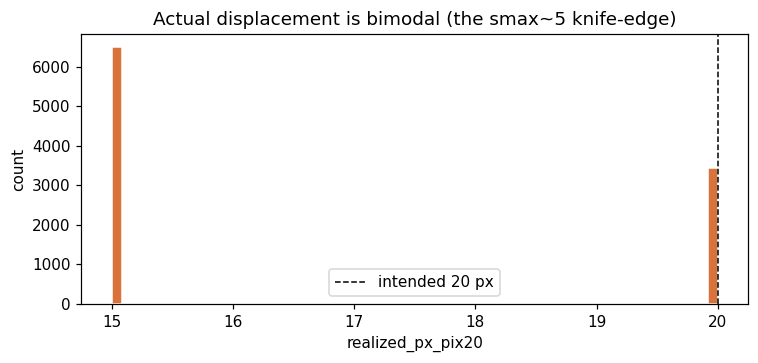

In [7]:
print("realized_px_pix20 (rounded) counts:")
print(sub["realized_px_pix20"].round(0).value_counts().sort_index())
print("\ndp_pix20 counts   :", dict(sub["dp_pix20"].value_counts().sort_index()))
print("frameA_index counts:", dict(sub["frameA_index"].value_counts().sort_index()))

frac20 = (sub["dp_pix20"] == 4).mean() * 100
frac15 = (sub["dp_pix20"] == 3).mean() * 100
print(f"\n~20 px (dp=4): {frac20:5.1f}%     ~15 px (dp=3): {frac15:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(sub["realized_px_pix20"], bins=60, color="#d8743b", edgecolor="white", lw=0.3)
ax.axvline(20, color="k", ls="--", lw=1, label="intended 20 px")
ax.set_xlabel("realized_px_pix20"); ax.set_ylabel("count")
ax.set_title("Actual displacement is bimodal (the smax~5 knife-edge)"); ax.legend()
fig.tight_layout(); plt.show()

## 6. Visualize image pairs (inputs) + velocity labels

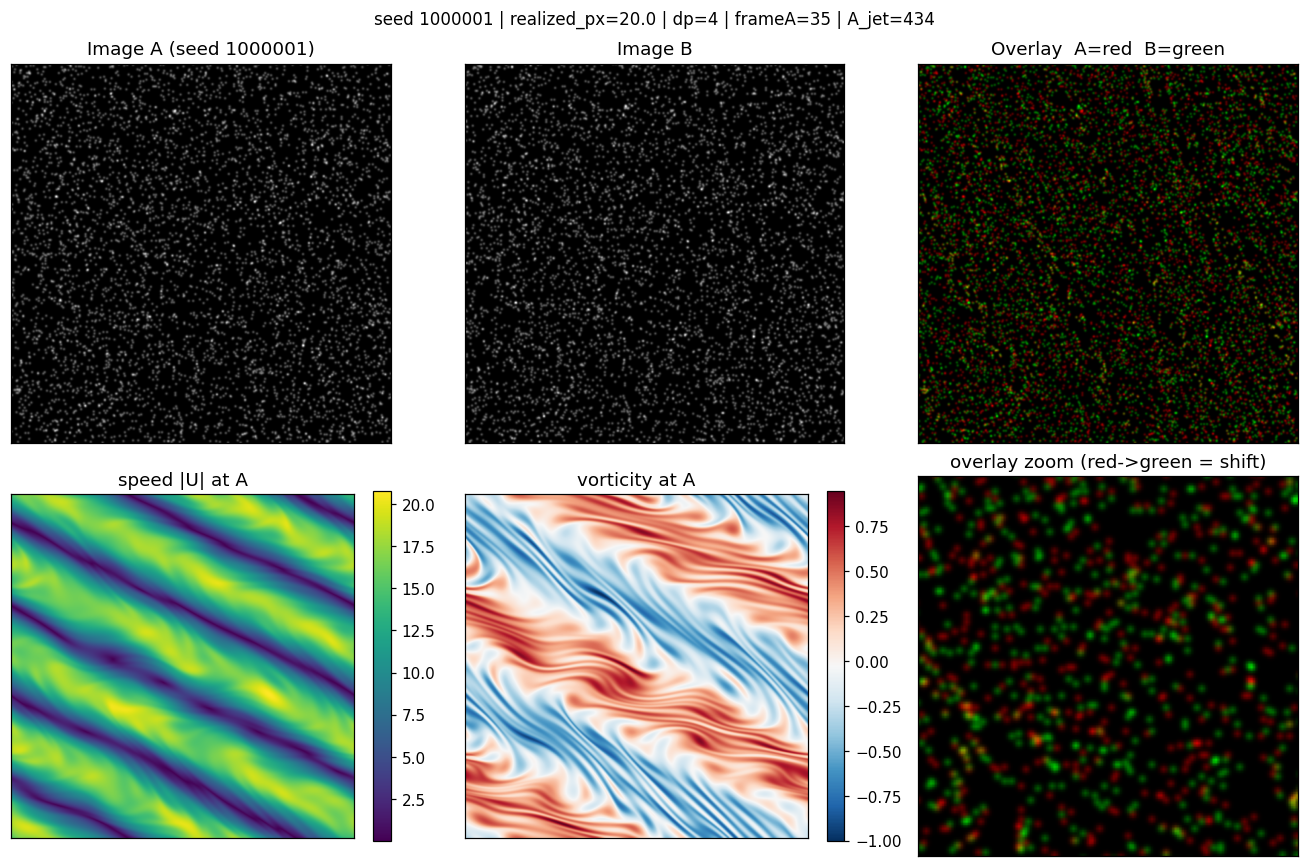

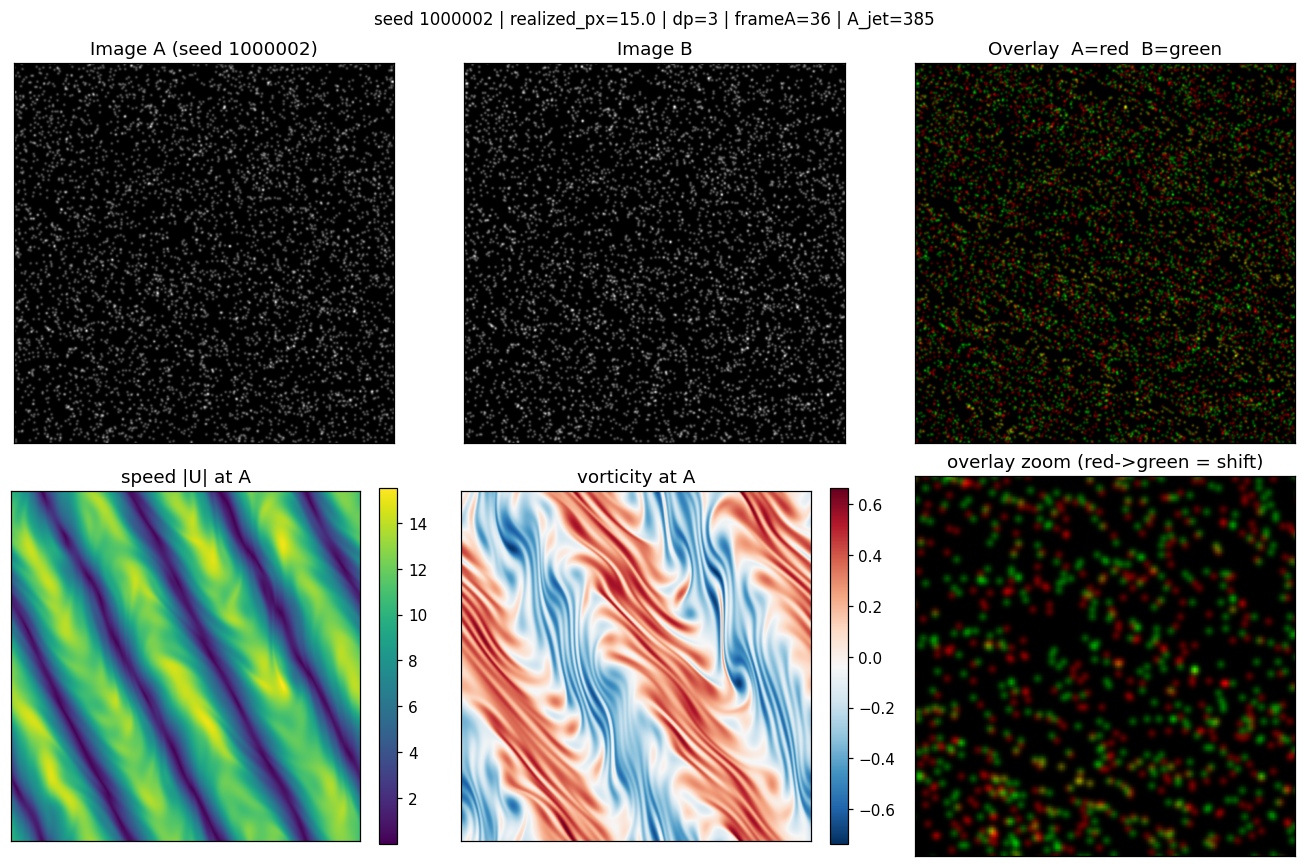

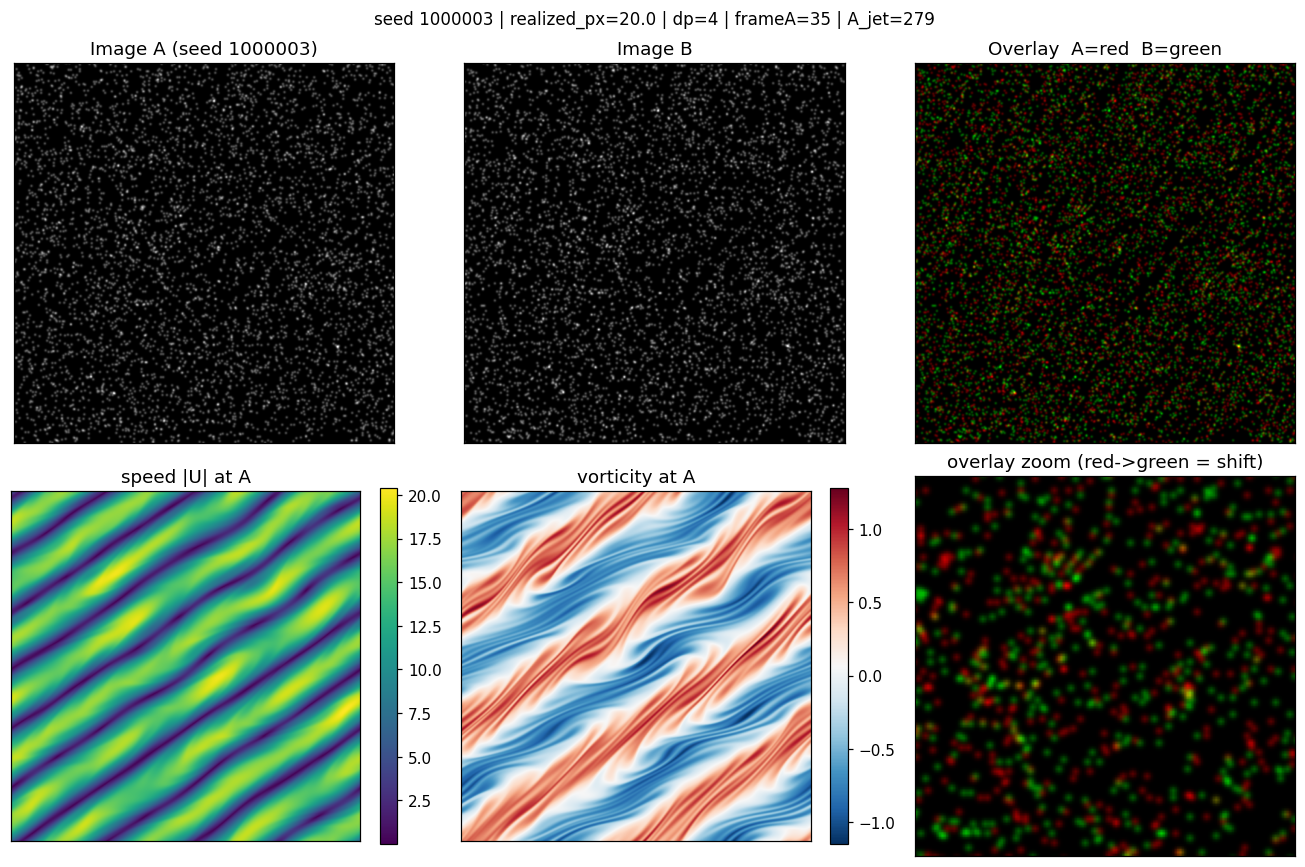

In [8]:
def show_sample(seed):
    d = load_pair(pair_path(seed))
    A, B = d["A"], d["B"]
    spd = speed(d["uA"], d["vA"]); w = vorticity(d["uA"], d["vA"])
    row = sub[sub.seed == seed].iloc[0]
    fig, ax = plt.subplots(2, 3, figsize=(12, 8))
    ax[0,0].imshow(A, cmap="gray");                ax[0,0].set_title(f"Image A (seed {seed})")
    ax[0,1].imshow(B, cmap="gray");                ax[0,1].set_title("Image B")
    ov = np.zeros((*A.shape, 3), np.uint8); ov[..., 0] = A; ov[..., 1] = B
    ax[0,2].imshow(ov);                            ax[0,2].set_title("Overlay  A=red  B=green")
    im = ax[1,0].imshow(spd, cmap="viridis");      ax[1,0].set_title("speed |U| at A"); fig.colorbar(im, ax=ax[1,0], fraction=.046)
    im = ax[1,1].imshow(w, cmap="RdBu_r");         ax[1,1].set_title("vorticity at A"); fig.colorbar(im, ax=ax[1,1], fraction=.046)
    z = slice(160, 320)
    ax[1,2].imshow(ov[z, z]);                      ax[1,2].set_title("overlay zoom (red->green = shift)")
    for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f"seed {seed} | realized_px={row.realized_px_pix20:.1f} | dp={int(row.dp_pix20)} "
                 f"| frameA={int(row.frameA_index)} | A_jet={row.A_jet_amplitude:.0f}", fontsize=11)
    fig.tight_layout(); plt.show()

for s in present[:3]:
    show_sample(s)

## 7. Label sanity checks

The velocity fields are the training labels, so they must be **finite** and produce
**displacement magnitudes of the right order**. We also check that B genuinely differs from
A (decorrelation grows with displacement).

fields with non-finite values: 0 (of 800 field-arrays)


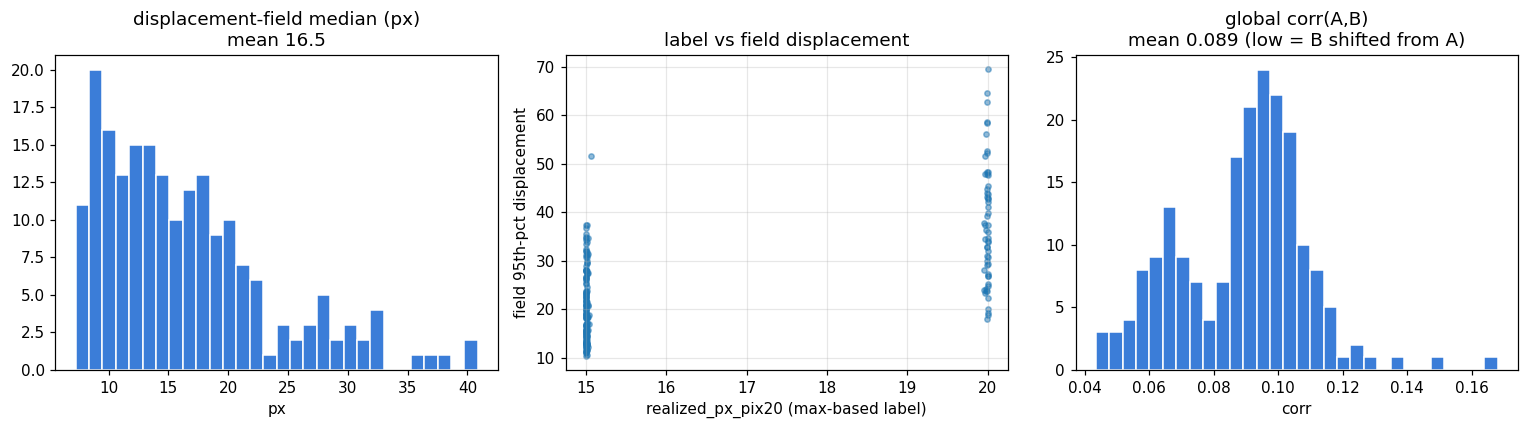

Field displacement magnitudes sit in the 15-20 px band -> labels are consistent with the bin.
Global corr(A,B) is low/positive -> B is a genuinely displaced version of A (expected for ~15-20 px).


In [9]:
rng = np.random.default_rng(0)
samp = rng.choice(present, size=min(200, len(present)), replace=False)
rows = sub.set_index("seed")

n_nonfinite = 0
disp_med, disp_p95, ab_corr, lbl = [], [], [], []
for s in samp:
    d = load_pair(pair_path(int(s))); r = rows.loc[s]
    for k in ["uA", "vA", "uB", "vB"]:
        if not np.isfinite(d[k]).all(): n_nonfinite += 1
    dt_pair = r["dp_pix20"] * r["dt_save"]
    dmag = speed((d["uA"]+d["uB"])/2, (d["vA"]+d["vB"])/2) * dt_pair   # mean-vel displacement field (px)
    disp_med.append(np.median(dmag)); disp_p95.append(np.percentile(dmag, 95))
    A = d["A"].astype(np.float32).ravel(); B = d["B"].astype(np.float32).ravel()
    A -= A.mean(); B -= B.mean()
    ab_corr.append(float((A @ B) / (np.linalg.norm(A)*np.linalg.norm(B) + 1e-9)))
    lbl.append(r["realized_px_pix20"])

disp_med = np.array(disp_med); disp_p95 = np.array(disp_p95)
ab_corr = np.array(ab_corr); lbl = np.array(lbl)
print(f"fields with non-finite values: {n_nonfinite} (of {len(samp)*4} field-arrays)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(disp_med, bins=30, color="#3b7dd8", edgecolor="white")
ax[0].set_title(f"displacement-field median (px)\nmean {disp_med.mean():.1f}"); ax[0].set_xlabel("px")
ax[1].scatter(lbl, disp_p95, s=12, alpha=.5)
ax[1].set_xlabel("realized_px_pix20 (max-based label)"); ax[1].set_ylabel("field 95th-pct displacement")
ax[1].set_title("label vs field displacement"); ax[1].grid(alpha=.3)
ax[2].hist(ab_corr, bins=30, color="#3b7dd8", edgecolor="white")
ax[2].set_title(f"global corr(A,B)\nmean {ab_corr.mean():.3f} (low = B shifted from A)"); ax[2].set_xlabel("corr")
fig.tight_layout(); plt.show()
print("Field displacement magnitudes sit in the 15-20 px band -> labels are consistent with the bin.")
print("Global corr(A,B) is low/positive -> B is a genuinely displaced version of A (expected for ~15-20 px).")

### 7b. (Exploratory) orientation / warp probe — optional

A stricter check: advect image A by the displacement field and see if it lines up with B.
This is sensitive to the Julia→h5py **axis convention** (which image axis is `u` vs `v`, and sign),
so we try all four conventions and report which best improves `corr(·,B)`. This is a *diagnostic for
orientation*, **not** a pass/fail on the data — a forward-Euler warp over a 4-frame gap is only
approximate. Hand this to whoever sets up the training data loader to lock the convention.

In [10]:
from scipy.ndimage import map_coordinates

def corr(x, y):
    x = x.ravel() - x.mean(); y = y.ravel() - y.mean()
    return float((x @ y) / (np.linalg.norm(x)*np.linalg.norm(y) + 1e-9))

def warp_probe(seed):
    d = load_pair(pair_path(seed)); r = rows.loc[seed]
    A = d["A"].astype(np.float32); B = d["B"].astype(np.float32)
    dt_pair = r["dp_pix20"] * r["dt_save"]
    u = (d["uA"]+d["uB"])/2 * dt_pair; v = (d["vA"]+d["vB"])/2 * dt_pair
    H, W = A.shape; yy, xx = np.mgrid[0:H, 0:W]
    base = corr(A, B)
    out = {"baseline corr(A,B)": round(base, 3)}
    for name, (dy, dx) in {
        "u->x, v->y":   ( v,  u),
        "u->y, v->x":   ( u,  v),
        "u->x,-v->y":   (-v,  u),
        "-u->x, v->y":  ( v, -u),
    }.items():
        Aw = map_coordinates(A, [yy + dy, xx + dx], order=1, mode="nearest")
        out[name] = round(corr(Aw, B), 3)
    return out

for s in present[:4]:
    print(f"seed {s}:", warp_probe(s))
print("\nIf one convention clearly beats the baseline, that's the correct (u,v)->(axis,sign) mapping.")

seed 1000001: {'baseline corr(A,B)': 0.071, 'u->x, v->y': -0.004, 'u->y, v->x': 0.036, 'u->x,-v->y': 0.006, '-u->x, v->y': 0.009}
seed 1000002: {'baseline corr(A,B)': 0.099, 'u->x, v->y': 0.023, 'u->y, v->x': 0.104, 'u->x,-v->y': 0.013, '-u->x, v->y': 0.011}
seed 1000003: {'baseline corr(A,B)': 0.064, 'u->x, v->y': 0.016, 'u->y, v->x': 0.039, 'u->x,-v->y': 0.005, '-u->x, v->y': -0.001}
seed 1000004: {'baseline corr(A,B)': 0.082, 'u->x, v->y': 0.032, 'u->y, v->x': 0.121, 'u->x,-v->y': 0.013, '-u->x, v->y': 0.012}

If one convention clearly beats the baseline, that's the correct (u,v)->(axis,sign) mapping.


## 8. Flow diversity — independent flows across seeds

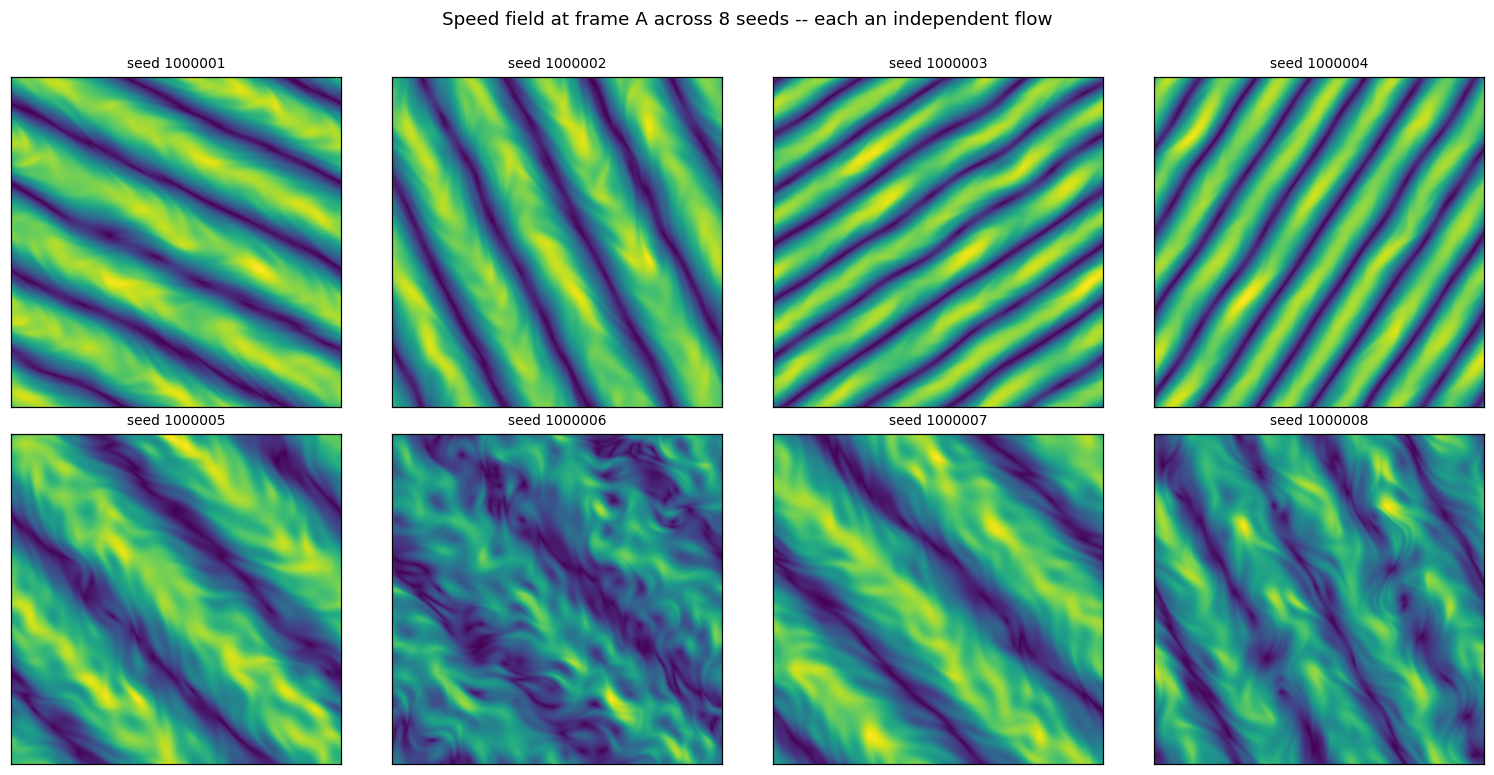

In [11]:
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for a, s in zip(ax.ravel(), present[:8]):
    d = load_pair(pair_path(s))
    a.imshow(speed(d["uA"], d["vA"]), cmap="viridis")
    a.set_title(f"seed {s}", fontsize=9); a.set_xticks([]); a.set_yticks([])
fig.suptitle("Speed field at frame A across 8 seeds -- each an independent flow", y=1.0)
fig.tight_layout(); plt.show()

## 9. Summary verdict

In [12]:
print("=" * 54)
print("  SUBSET QC SUMMARY  --", DATA_DIR.split('/')[-1])
print("=" * 54)
print(f"samples (pix20 files)      : {len(present)}")
print(f"metadata TOMLs             : {len(seeds_meta)}")
print(f"manifest rows matched      : {len(sub)}")
print(f"corrupt / invalid files    : {len(bad)}")
print(f"missing metadata           : {len(seeds_disk - seeds_meta)}")
print(f"seeds not in manifest      : {len(seeds_disk - set(mf['seed']))}")
print(f"duplicate seeds            : {len(present) - len(set(present))}")
print(f"seed block contiguous      : {present == list(range(min(present), min(present)+len(present)))}")
print("-" * 54)
print(f"realized_px_pix20 median   : {sub['realized_px_pix20'].median():.2f} px")
print(f"  ~20px (dp=4) fraction    : {(sub['dp_pix20']==4).mean()*100:.1f}%")
print(f"  ~15px (dp=3) fraction    : {(sub['dp_pix20']==3).mean()*100:.1f}%")
print(f"smax median                : {sub['smax'].median():.3f} px/frame")
print(f"frame A indices            : {sorted(sub['frameA_index'].unique())}")
print(f"A_jet amplitude range      : [{sub['A_jet_amplitude'].min():.0f}, {sub['A_jet_amplitude'].max():.0f}]")
print("=" * 54)
integrity_ok = (len(bad) == 0
                and len(seeds_disk - seeds_meta) == 0
                and len(seeds_disk - set(mf['seed'])) == 0
                and len(present) == len(set(present)))
print("INTEGRITY :", "OK -- files, metadata, manifest all consistent" if integrity_ok else "SEE FLAGS ABOVE")
print("NOTE      : 'pix20' is a mix of ~15 px (dp=3) and ~20 px (dp=4); filter on")
print("            realized_px_pix20 / dp_pix20, not the bin name, when training.")

  SUBSET QC SUMMARY  -- subset_pix20_10000
samples (pix20 files)      : 10000
metadata TOMLs             : 10000
manifest rows matched      : 10000
corrupt / invalid files    : 0
missing metadata           : 0
seeds not in manifest      : 0
duplicate seeds            : 0
seed block contiguous      : True
------------------------------------------------------
realized_px_pix20 median   : 15.01 px
  ~20px (dp=4) fraction    : 34.7%
  ~15px (dp=3) fraction    : 65.3%
smax median                : 5.001 px/frame
frame A indices            : [35, 36]
A_jet amplitude range      : [150, 450]
INTEGRITY : OK -- files, metadata, manifest all consistent
NOTE      : 'pix20' is a mix of ~15 px (dp=3) and ~20 px (dp=4); filter on
            realized_px_pix20 / dp_pix20, not the bin name, when training.
